# 3주차 실습
# MNIST handwritten digit classification with MLPs

이번 과제에서는 **PyTorch**를 사용하여 MNIST 숫자를 분류하는 다층 퍼셉트론(MLP) 모델을 학습하게 됨.

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import numpy as np
import matplotlib.pyplot as plt
import os

print('Using PyTorch version:', torch.__version__)
if torch.cuda.is_available():
    print('Using GPU, device name:', torch.cuda.get_device_name(0))
    device = torch.device('cuda')
else:
    print('No GPU found, using CPU instead.')
    device = torch.device('cpu')

Using PyTorch version: 2.11.0+cpu
No GPU found, using CPU instead.


## Loading data

PyTorch has two classes from [`torch.utils.data` to work with data](https://pytorch.org/docs/stable/data.html#module-torch.utils.data):
- [Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) which represents the actual data items, such as images or pieces of text, and their labels
- [DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) which is used for processing the dataset in batches in an efficient manner.

Here we will use TorchVision and `torchvision.datasets` which provides easy access to [many common visual datasets](https://pytorch.org/vision/stable/datasets.html). In this example we'll use the [MNIST class](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) for loading the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database).

In [2]:
batch_size = 32

slurm_project = os.getenv('SLURM_JOB_ACCOUNT')
data_dir = os.path.join('/scratch', slurm_project, 'data') if slurm_project else './data'
print('data_dir =', data_dir)

train_dataset = datasets.MNIST(data_dir, train=True, download=True, transform=ToTensor())
test_dataset = datasets.MNIST(data_dir, train=False, transform=ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

data_dir = ./data


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.77MB/s]


The data loaders provide a way of iterating (making a loop over) the datasets, each time getting a new batch of data with the given batch size.

The first element of the data batch (`data`) is a 4th-order tensor of size (`batch_size`, 1, 28, 28), i.e. it consists of a batch of images of size 1x28x28 pixels, where the first value is the number of color channels (only 1 in this case as it's gray scale).

The second element of the batch (`target`) is a vector containing the correct (or "target") classes ("0", "1", ..., "9") for each training digit.

In [3]:
for (data, target) in train_loader:
    print('data:', data.size(), 'type:', data.type())
    print('target:', target.size(), 'type:', target.type())
    break

data: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
target: torch.Size([32]) type: torch.LongTensor


Here are the first 10 training digits:

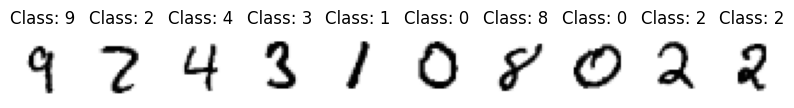

In [4]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(data[i,:,:,:].numpy().reshape(28,28), cmap="gray_r")
    plt.title('Class: '+str(target[i].item()))

## Multi-layer perceptron (MLP) network

In PyTorch, a neural network is defined as a Python class. It needs to have two methods:

- `__init__()` which initializes the layers used in the network
- `forward()` which defines how the network performs a forward pass

PyTorch will then automatically generate a `backward()` method that computes the gradients based on the computation done in the forward pass.

All the [neural network building blocks defined in PyTorch can be found in the torch.nn documentation](https://pytorch.org/docs/stable/nn.html).

We use `nn.Sequential` to more easily create a simple sequental neural network:

- First we need to "flatten" the 2D image into a vector with `nn.Flatten`

- Next a fully-connected layer with 20 neurons is created with `nn.Linear`. Note that we need to specify the number of input and output connections. In this case there are 28x28=784 inputs, and 20 outputs

- Next, a ReLU non-linear activation

- Finally the output of the last layer needs to be a 10-dimensional vector to match the ground truth of ten classes (the ten digits).

The output of the last layer should be normalized with softmax, but this is actually included implicitly in the loss function in PyTorch (see below).

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),  #여러 차원을 한줄로 펴줌.. linear은 1차원 입력만 받기 때문 784짜리 벡터로변환
            nn.Linear(28*28, 20),  #입력:784->출력:20 / Wx+b
            nn.ReLU(), #activation
            nn.Linear(20, 10) #은닉층20->10출력층, activation 적용전
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleMLP().to(device)
print(model)

SimpleMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=20, bias=True)
    (2): ReLU()
    (3): Linear(in_features=20, out_features=10, bias=True)
  )
)


# Training the model

In order to train the model we need to define a loss function and an optimizer.

For a classification task we typically use the cross entropy loss. For this we can use the class [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

**Note:** if you read the documentation of `CrossEntropyLoss` carefully you will see that it expects the unnormalized raw outputs of the model as softmax is included implicitly in PyTorch's implementation of `CrossEntropyLoss`. This is why we don't need to explicitly use softmax in the network definition above.

Finally, we need to define an optimizer, which tells how to update the model parameters based on the computed gradients. There are [several different optimizer algorithms implemented in PyTorch](https://pytorch.org/docs/stable/optim.html#algorithms).

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In PyTorch we have to write the training loop ourselves.

The code below consists of two loops:

- The outer loop goes over a number of *epochs*. An epoch is a single pass through the whole training data.
- The inner loop goes through the whole dataset, a batch at a time. Here we have defined the batch size to be 32, so images are handled 32 at a time.

For each batch we:

- Copy the data to the GPU with the `.to(device)` method. If we don't have a GPU, these commands will not do anything.

- Do a forward pass, which is as simple as: `output = model(data)`

- Finally we calculate the loss - that is the error between the output of the network and the target we want to get - using the `criterion` function we defined earlier

- The last lines do the backward propagation with `loss.backward()`, the weights are updated with `optimizer.step()` and finally we need to zero the gradient counters with `optimizer.zero_grad()`.

First, a helper function to calculate the number of correctly classified digits.

In [7]:
def correct(output, target):
    predicted_digits = output.argmax(1)                            # pick digit with largest network output
    correct_ones = (predicted_digits == target).type(torch.float)  # 1.0 for correct, 0.0 for incorrect
    return correct_ones.sum().item()                               # count number of correct ones


Next a function for a single training epoch.

In [8]:
def train(data_loader, model, criterion, optimizer):
    model.train()

    num_batches = len(data_loader)
    num_items = len(data_loader.dataset)

    total_loss = 0
    total_correct = 0
    for data, target in data_loader:
        # Copy data and targets to GPU
        data = data.to(device)
        target = target.to(device)

        # Do a forward pass
        output = model(data)

        # Calculate the loss
        loss = criterion(output, target)
        total_loss += loss

        # Count number of correct digits
        total_correct += correct(output, target)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()   #다음 batch를 위해 grad를 비운다.

    train_loss = total_loss/num_batches
    accuracy = total_correct/num_items
    print(f"Average loss: {train_loss:7f}, accuracy: {accuracy:.2%}")


In [9]:
%%time

epochs = 10
for epoch in range(epochs):
    print(f"Training epoch: {epoch+1}")
    train(train_loader, model, criterion, optimizer)

Training epoch: 1
Average loss: 0.432027, accuracy: 88.24%
Training epoch: 2
Average loss: 0.253442, accuracy: 92.67%
Training epoch: 3
Average loss: 0.211181, accuracy: 93.86%
Training epoch: 4
Average loss: 0.182405, accuracy: 94.71%
Training epoch: 5
Average loss: 0.162208, accuracy: 95.33%
Training epoch: 6
Average loss: 0.149130, accuracy: 95.67%
Training epoch: 7
Average loss: 0.137804, accuracy: 95.94%
Training epoch: 8
Average loss: 0.130734, accuracy: 96.18%
Training epoch: 9
Average loss: 0.123946, accuracy: 96.28%
Training epoch: 10
Average loss: 0.117835, accuracy: 96.53%
CPU times: user 1min 8s, sys: 77.4 ms, total: 1min 8s
Wall time: 1min 9s


### Inference (Test)

For a better measure of the quality of the model, let's see the model accuracy for the test data.

The code is similar to the training code: we just loop over the whole testset, but no need to do backpropagation or calculate any gradients this time.

In [10]:
def test(test_loader, model, criterion):
    model.eval()

    num_batches = len(test_loader)
    num_items = len(test_loader.dataset)

    test_loss = 0
    total_correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            # Copy data and targets to GPU
            data = data.to(device)
            target = target.to(device)

            # Do a forward pass
            output = model(data)

            # Calculate the loss
            loss = criterion(output, target)
            test_loss += loss.item()

            # Count number of correct digits
            total_correct += correct(output, target)

    test_loss = test_loss/num_batches
    accuracy = total_correct/num_items

    print(f"Testset accuracy: {100*accuracy:>0.1f}%, average loss: {test_loss:>7f}")

In [11]:
test(test_loader, model, criterion)

Testset accuracy: 95.8%, average loss: 0.141376


# Problem 1


## 2 개의 Linear layer 로 이루어진 모델을 구현하시오.


위와 동일하게 MLP 모델을 구현하면서 정확도를 더 향상시키기 위한 새로운 MLP 모델을 구현하시오.
새로운 MLP 모델은 **두 개의 linear layer**을 가져야 함.

각 linear layer는 아래의 구성 요소대로 구현하시오:

- 50 units
- ReLU activation function
- 각 linear layer 다음에 dropout layer (dropout 비율 값 0.2이용) 를 추가하시오. - hint: try [nn.Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#torch.nn.Dropout)

Dropout은 학습 과정에서 입력의 일부를 무작위로 0으로 설정하는 기법으로, 정규화의 한 방법이며 때로는 과적합을 방지하는 데 도움이 됨.

[PyTorch 문서](https://pytorch.org/docs/stable/index.html)를 참고하고, 특히 [모든 인공 신경망 구성 요소는 `torch.nn` 문서](https://pytorch.org/docs/stable/nn.html)에서 확인하실 수 있음.


In [12]:
class TwoLayerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            # Problem 1: Add layers here

            nn.Flatten(),
            nn.Linear(28*28, 50),
            nn.ReLU(),
            nn.Dropout(0.2),  #학습할때 일부 뉴런을 랜덤으로 꺼버림 레이어의 랜덤값 몇개.. activation 끝난 뒤에 보통 넣는다.
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(50, 10)  ##은닉층50->10출력층, activation 적용전


        )

    def forward(self, x):
        return self.layers(x)


In [13]:
your_model = TwoLayerMLP()
print(your_model)

assert len(your_model.layers) > 0, "ERROR: You need to write the missing model definition above!"
your_model = your_model.to(device)

TwoLayerMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=50, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=50, out_features=10, bias=True)
  )
)


In [14]:
your_criterion = nn.CrossEntropyLoss()
your_optimizer = torch.optim.Adam(your_model.parameters())

In [15]:
%%time

epochs = 10 #전체 데이터셋 학습시키는 횟수
for epoch in range(epochs):
    print(f"Epoch: {epoch+1} ...")
    train(train_loader, your_model, your_criterion, your_optimizer)

Epoch: 1 ...
Average loss: 0.485431, accuracy: 85.16%
Epoch: 2 ...
Average loss: 0.255630, accuracy: 92.42%
Epoch: 3 ...
Average loss: 0.213865, accuracy: 93.61%
Epoch: 4 ...
Average loss: 0.187732, accuracy: 94.42%
Epoch: 5 ...
Average loss: 0.172905, accuracy: 94.69%
Epoch: 6 ...
Average loss: 0.162684, accuracy: 95.08%
Epoch: 7 ...
Average loss: 0.153918, accuracy: 95.29%
Epoch: 8 ...
Average loss: 0.147947, accuracy: 95.47%
Epoch: 9 ...
Average loss: 0.140519, accuracy: 95.65%
Epoch: 10 ...
Average loss: 0.138707, accuracy: 95.63%
CPU times: user 1min 16s, sys: 63.9 ms, total: 1min 16s
Wall time: 1min 16s


In [16]:
test(test_loader, your_model, your_criterion)

Testset accuracy: 97.1%, average loss: 0.100195


# Problem 2 (과제 문제)

## 더 향상된 test accuracy(테스트 셋을 이용한 정확도)를 얻기 위해 Model tuning 을 수행하고 tuning을 통해 얻은 test accuracy와 Problem 1에서 얻은 test accuracy 를 비교하시오.


분류 정확도를 향상시키기 위해 MLP 모델을 변경해서 얻은 분류 정확도를 비교해보고, 추가로 다양한 하이퍼파라미터를 이용하여 얻은 분류 정확도를 비교해보시오.

MLP 모델 변경 예: loss function(criterion) 변경, optimizer 변경, ReLU 외 다른 activation function으로 변경, Linear layer 개수 변경, 각 layer에서의 unit 개수 변경 등

In [17]:
# Problem 2: Modify your MLP model and compare the test accuracy between the modified MLP and the TwoLayerMLP above
class ModifiedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layers(x)

your_model = ModifiedMLP()

your_criterion = nn.CrossEntropyLoss()
your_optimizer = torch.optim.Adam(your_model.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):
    print(f"Epoch: {epoch+1} ...")
    train(train_loader, your_model, your_criterion, your_optimizer)

test(test_loader, your_model, your_criterion)


Epoch: 1 ...
Average loss: 0.257076, accuracy: 92.46%
Epoch: 2 ...
Average loss: 0.135598, accuracy: 95.88%
Epoch: 3 ...
Average loss: 0.110249, accuracy: 96.51%
Epoch: 4 ...
Average loss: 0.090952, accuracy: 97.06%
Epoch: 5 ...
Average loss: 0.080819, accuracy: 97.47%
Epoch: 6 ...
Average loss: 0.072428, accuracy: 97.69%
Epoch: 7 ...
Average loss: 0.066212, accuracy: 97.89%
Epoch: 8 ...
Average loss: 0.060169, accuracy: 98.02%
Epoch: 9 ...
Average loss: 0.057199, accuracy: 98.13%
Epoch: 10 ...
Average loss: 0.052610, accuracy: 98.26%
Testset accuracy: 98.4%, average loss: 0.053149


Problem 2에서 Model tuning한 모델의 accuracy가 98.4%,
Problem 1에서 구현한 모델의 accuracy가 97.1%으로
Model tuning한 모델의 정확도가 약 1.3%p 더 높다는 것을 확인할 수 있다.